In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [4]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from kret_sandbox.VIS import dtt

#### Load ENV

In [5]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

In [6]:
envconfig = EnvConfig()
cfg = envconfig

In [7]:
env = RideShareEnv(cfg)
G = env.graph

Assigned lambda values to nodes. Total lambda: 2.2013 (target: 2.3460)


In [8]:
s, info = env.reset()

In [9]:
SupplyDemandDF.space_config(envconfig)["shape"]

(3,)

In [10]:
action = env.action_space.sample()

In [11]:
# obs, reward, terminated, truncated, info = env.step(action)

In [12]:
veh, req, rides = get_obvs_tuple(env)

In [13]:
from waymo_agent.data_classes.supply_demand_df import SupplyDemandDF


get_sd_ratio(cfg, req, veh)[0]

np.float64(0.9999822711311133)

In [14]:
dtt([veh, rides], cols_per_row=1)

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 -0.032 
 0.210 
 0.989 
 0 
 -1 
 
 
 5 
 5 
 -0.398 
 0.033 
 0.764 
 0 
 -1 
 
 
 9 
 9 
 -0.114 
 0.016 
 0.787 
 0 
 -1 
 
 
 21 
 21 
 0.591 
 0.460 
 0.800 
 0 
 -1 
 
 
 22 
 22 
 -0.055 
 0.506 
 0.857 
 0 
 -1 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 5 
 -1 
 5 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 9 
 -1 
 9 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 21 
 -1 
 21 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 22 
 -1 
 22 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [15]:
ven, reqn, ridesn = get_obvs_tuple(env)

In [16]:
dtt([ven, reqn, ridesn], cols_per_row=1)

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 -0.032 
 0.210 
 0.989 
 0 
 -1 
 
 
 3 
 3 
 0.167 
 0.053 
 0.762 
 0 
 -1 
 
 
 9 
 9 
 -0.114 
 0.016 
 0.787 
 0 
 -1 
 
 
 13 
 13 
 0.186 
 0.123 
 0.872 
 0 
 -1 
 
 
 21 
 21 
 0.591 
 0.460 
 0.800 
 0 
 -1 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 
 
 
 
 0 
 2 
 2025-01-05 02:51:40.164963 
 11929 
 0.386 
 1.853 
 1.068 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 42432598 
 -0.197 
 0.142 
 42437379 
 -0.34 
 0.111 
 [42432598, 42455761, 42430688, 11017187937, 42453555, 42437379] 
 42432598 
 42455761 
 0.0 
 1067.514 
 
 
 8 
 -1 
 NaT 
 -1 
 -1.000 
 -1.000 
 -1.000 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.000 
 -1.000 
 -1 
 -1.00 
 -1.000 
 [] 
 -1 
 -1 
 -1.0 
 -1.000 
 
 
 21 
 -1 
 NaT 
 -1 
 -1.000 
 -1.000 
 -1.000 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.000 
 -1.000 
 -1 
 -1.00 
 -1.000 
 [] 
 -1 
 -1 
 -1.0 
 -1.000 
 
 
 31 
 -1 
 NaT 
 -1 
 -1.000 
 -1.000 
 -1.000 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.000 
 -1.000 
 -1 
 -1.00 
 -1.000 
 [] 
 -1 
 -1 
 -1.0 
 -1.000 
 
 
 43 
 -1 
 NaT 
 -1 
 -1.000 
 -1.000 
 -1.000 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.000 
 -1.000 
 -1 
 -1.00 
 -1.000 
 [] 
 -1 
 -1 
 -1.0 
 -1.000 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 3 
 -1 
 3 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 9 
 -1 
 9 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 13 
 -1 
 13 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 21 
 -1 
 21 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [17]:
fig, ax = env.render()

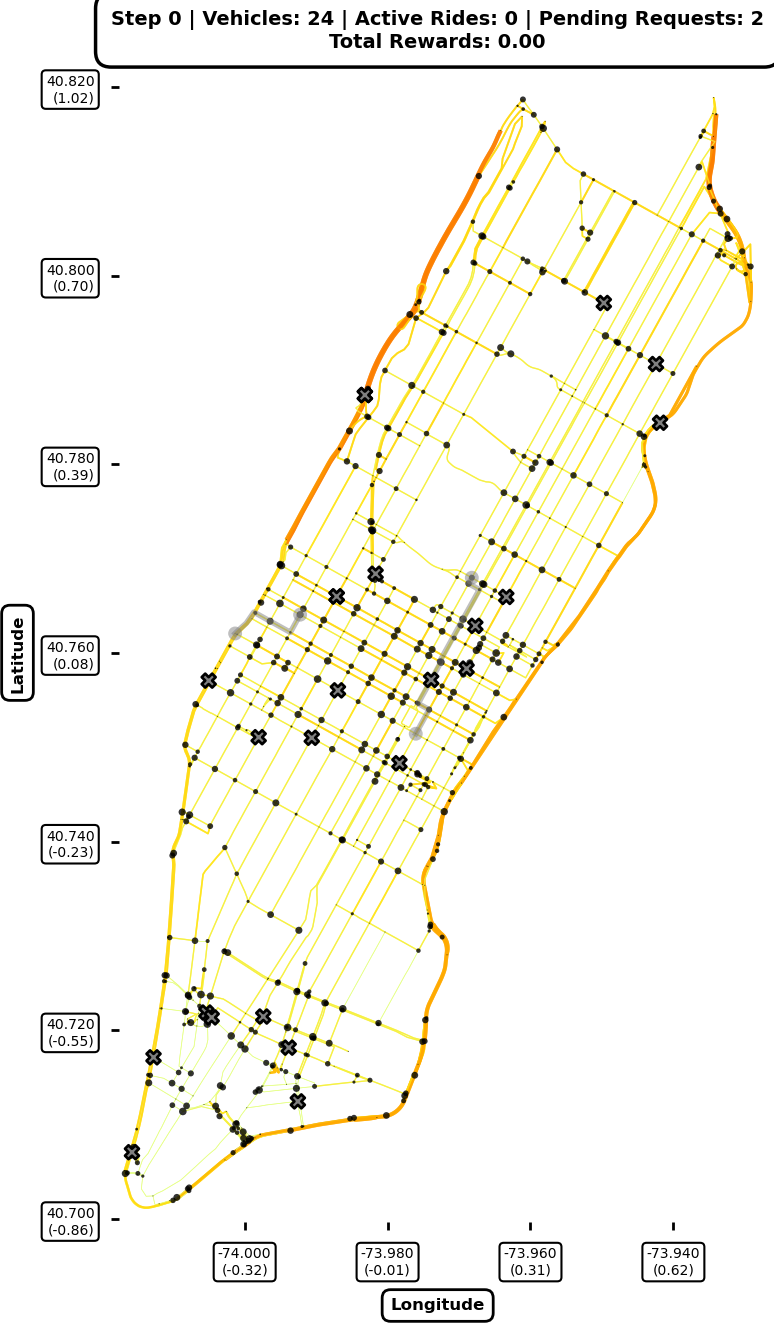

In [18]:
fig

In [19]:
out = env.step(action)

status
-10    48
 1      2
Name: count, dtype: int64 int64


In [20]:
fig, ax = env.render()

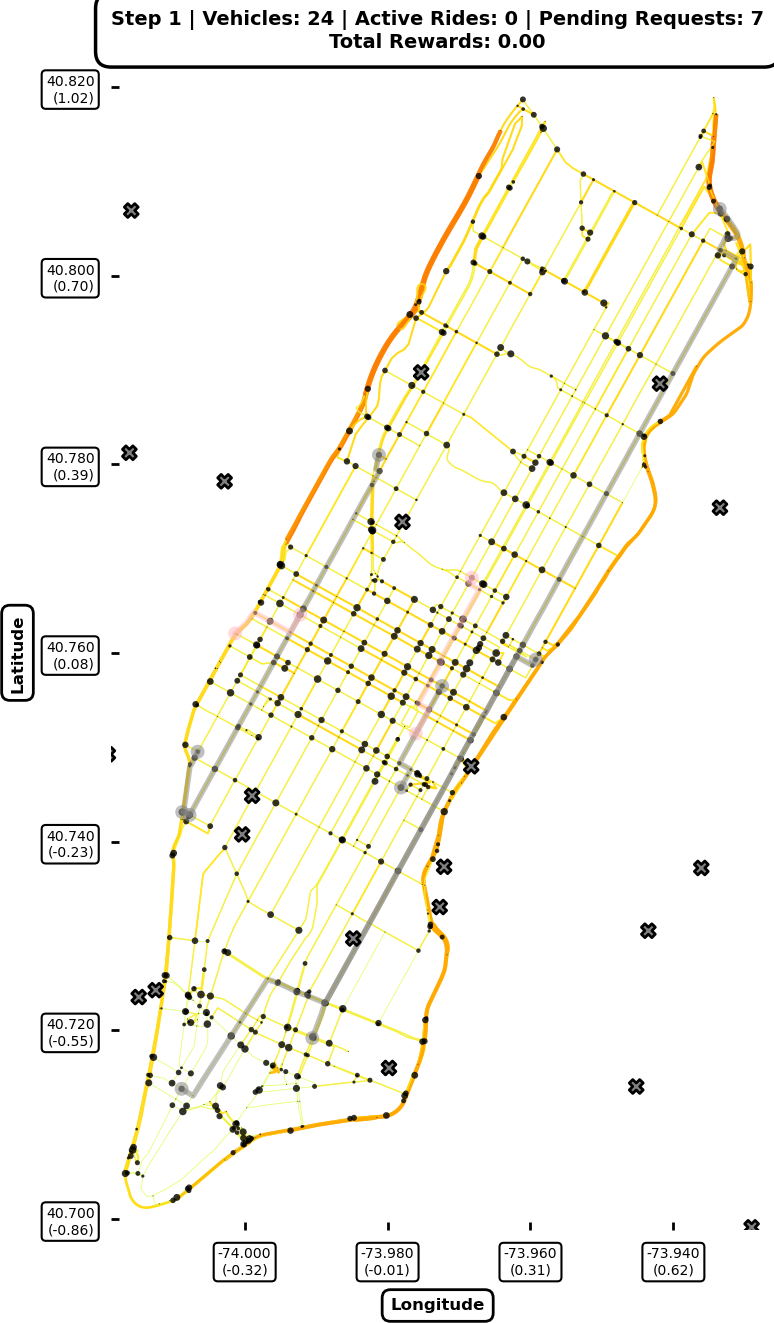

In [21]:
fig